# Car Dataset — Exploratory Data Analysis

**Dataset:** Car Features and MSRP (Kaggle, 11,914 rows, 16 features)

**Business Problem:** A manufacturer, dealership, or pricing analyst wants to understand what drives a vehicle's market price (MSRP) — to price new models competitively, identify which features justify a price premium, and spot unusual market segments (e.g. ultra-luxury or electric vehicles) that need separate pricing treatment.

**This notebook covers:**
- Q1: Count of cars by Make
- Q2: Average price by Engine Cylinder type
- Q3: Average city/highway mileage by Transmission Type
- Q4: Top 5 brands and top Vehicle Style by popularity
- Q5: Distribution, skewness, kurtosis, and IQR outlier analysis for 6 key features
- Correlation heatmap and scatter plot to visualize price relationships


In [1]:
import pandas as pd

In [2]:
df = pd.read_csv('Car Dataset.csv')

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11914 entries, 0 to 11913
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Make               11914 non-null  object 
 1   Model              11914 non-null  object 
 2   Year               11914 non-null  int64  
 3   Engine Fuel Type   11911 non-null  object 
 4   Engine HP          11845 non-null  float64
 5   Engine Cylinders   11884 non-null  float64
 6   Transmission Type  11914 non-null  object 
 7   Driven_Wheels      11914 non-null  object 
 8   Number of Doors    11908 non-null  float64
 9   Market Category    8172 non-null   object 
 10  Vehicle Size       11914 non-null  object 
 11  Vehicle Style      11914 non-null  object 
 12  highway MPG        11914 non-null  int64  
 13  city mpg           11914 non-null  int64  
 14  Popularity         11914 non-null  int64  
 15  MSRP               11914 non-null  int64  
dtypes: float64(3), int64(5

### Check for missing values

In [4]:
df.isnull().sum()

Make                    0
Model                   0
Year                    0
Engine Fuel Type        3
Engine HP              69
Engine Cylinders       30
Transmission Type       0
Driven_Wheels           0
Number of Doors         6
Market Category      3742
Vehicle Size            0
Vehicle Style           0
highway MPG             0
city mpg                0
Popularity              0
MSRP                    0
dtype: int64

In [5]:
df.head(4)

,Make,Model,Year,Engine Fuel Type,Engine HP,Engine Cylinders,Transmission Type,Driven_Wheels,Number of Doors,Market Category,Vehicle Size,Vehicle Style,highway MPG,city mpg,Popularity,MSRP
0,BMW,1 Series M,2011,premium unleaded (required),335.0,6.0,MANUAL,rear wheel drive,2.0,"Factory Tuner,Luxury,High-Performance",Compact,Coupe,26,19,3916,46135
1,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Convertible,28,19,3916,40650
2,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,High-Performance",Compact,Coupe,28,20,3916,36350
3,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Coupe,28,18,3916,29450


In [6]:
# Q1_COUNT

In [7]:
df['Make'].value_counts()

Make
Chevrolet        1123
Ford              881
Volkswagen        809
Toyota            746
Dodge             626
Nissan            558
GMC               515
Honda             449
Mazda             423
Cadillac          397
Mercedes-Benz     353
Suzuki            351
BMW               334
Infiniti          330
Audi              328
Hyundai           303
Volvo             281
Subaru            256
Acura             252
Kia               231
Mitsubishi        213
Lexus             202
Buick             196
Chrysler          187
Pontiac           186
Lincoln           164
Oldsmobile        150
Land Rover        143
Porsche           136
Saab              111
Aston Martin       93
Plymouth           82
Bentley            74
Ferrari            69
FIAT               62
Scion              60
Maserati           58
Lamborghini        52
Rolls-Royce        31
Lotus              29
Tesla              18
HUMMER             17
Maybach            16
Alfa Romeo          5
McLaren             5
Spyke

In [8]:
# Q2_Average price for each Engine Cylinder type:

In [9]:
df.groupby('Engine Cylinders')['MSRP'].mean()

Engine Cylinders
0.0     5.061509e+04
3.0     9.698000e+03
4.0     2.380116e+04
5.0     2.081885e+04
6.0     3.421924e+04
8.0     6.148701e+04
10.0    1.841238e+05
12.0    2.851778e+05
16.0    1.757224e+06
Name: MSRP, dtype: float64

In [10]:
# Q3_Average city & highway mileage by Transmission Type

In [11]:
df.groupby('Transmission Type')[['city mpg', 'highway MPG']].mean()

,city mpg,highway MPG
Transmission Type,,
AUTOMATED_MANUAL,20.800319,29.214058
AUTOMATIC,18.939148,25.782966
DIRECT_DRIVE,110.794118,97.970588
MANUAL,19.666440,26.881772
UNKNOWN,14.473684,20.473684


In [12]:
# Q4_Top 5 brands and top Vehicle Style by popularity

In [13]:
df.groupby('Make')['Popularity'].mean().sort_values(ascending=False).head(5)

Make
Ford       5657.0
BMW        3916.0
Audi       3105.0
Ferrari    2774.0
Honda      2202.0
Name: Popularity, dtype: float64

In [14]:
# Q5_Distribution, skewness, kurtosis, and IQR outliers

In [15]:
# ENGINE HP

In [16]:
data = df['Engine HP'].dropna()
print("Skewness:", data.skew())
print("Kurtosis:", data.kurt())

Q1 = data.quantile(0.25)
Q3 = data.quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
outliers = data[(data < lower) | (data > upper)]
print("Bounds:", lower, upper)
print("Outliers:", len(outliers))

Skewness: 1.291229813313272
Kurtosis: 2.3238844260297853
Bounds: -25.0 495.0
Outliers: 509


In [17]:
# ENGINE CYLINDERS

In [18]:
data = df['Engine Cylinders'].dropna()
print("Skewness:", data.skew())
print("Kurtosis:", data.kurt())

Q1 = data.quantile(0.25)
Q3 = data.quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
outliers = data[(data < lower) | (data > upper)]
print("Bounds:", lower, upper)
print("Outliers:", len(outliers))

Skewness: 0.9645421531686647
Kurtosis: 1.9743157245560794
Bounds: 1.0 9.0
Outliers: 357


In [19]:
# HIGHWAY MPG

In [20]:
data = df['highway MPG'].dropna()
print("Skewness:", data.skew())
print("Kurtosis:", data.kurt())

Q1 = data.quantile(0.25)
Q3 = data.quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
outliers = data[(data < lower) | (data > upper)]
print("Bounds:", lower, upper)
print("Outliers:", len(outliers))

Skewness: 7.573931188779522
Kurtosis: 181.62736433184074
Bounds: 10.0 42.0
Outliers: 192


In [21]:
# CITY MPG

In [22]:
data = df['city mpg'].dropna()
print("Skewness:", data.skew())
print("Kurtosis:", data.kurt())

Q1 = data.quantile(0.25)
Q3 = data.quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
outliers = data[(data < lower) | (data > upper)]
print("Bounds:", lower, upper)
print("Outliers:", len(outliers))

Skewness: 7.106680706149128
Kurtosis: 74.62348660098436
Bounds: 7.0 31.0
Outliers: 316


In [23]:
# POPULARITY

In [24]:
data = df['Popularity'].dropna()
print("Skewness:", data.skew())
print("Kurtosis:", data.kurt())

Q1 = data.quantile(0.25)
Q3 = data.quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
outliers = data[(data < lower) | (data > upper)]
print("Bounds:", lower, upper)
print("Outliers:", len(outliers))

Skewness: 1.653442528639718
Kurtosis: 2.277089663156133
Bounds: -1641.0 4199.0
Outliers: 881


In [25]:
# MSRP

In [26]:
data = df['MSRP'].dropna()
print("Skewness:", data.skew())
print("Kurtosis:", data.kurt())

Q1 = data.quantile(0.25)
Q3 = data.quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
outliers = data[(data < lower) | (data > upper)]
print("Bounds:", lower, upper)
print("Outliers:", len(outliers))

Skewness: 11.771987129334969
Kurtosis: 268.926276476316
Bounds: -10846.875 74078.125
Outliers: 996


In [27]:
# DIAGRAMS

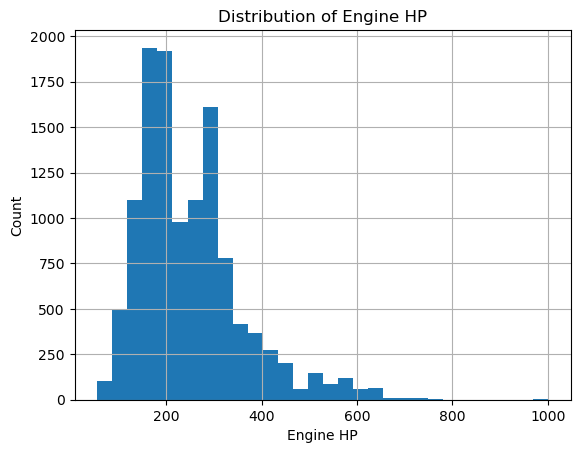

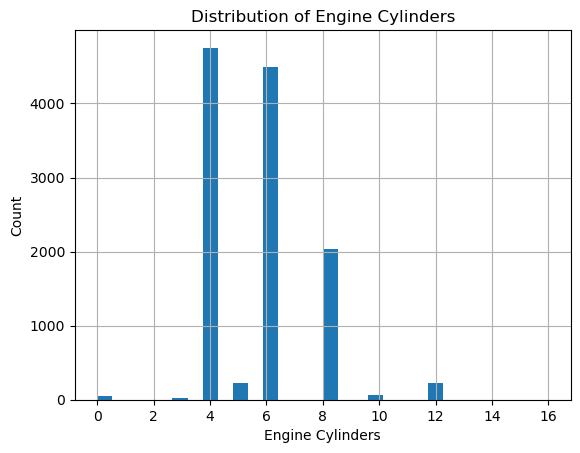

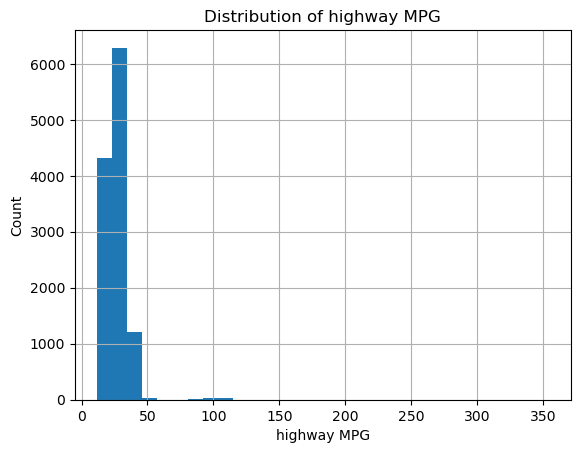

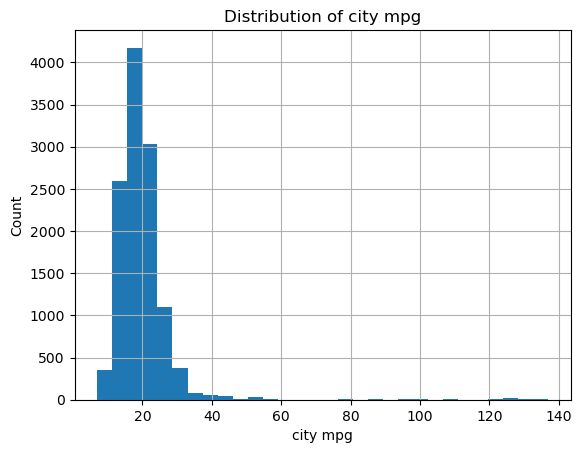

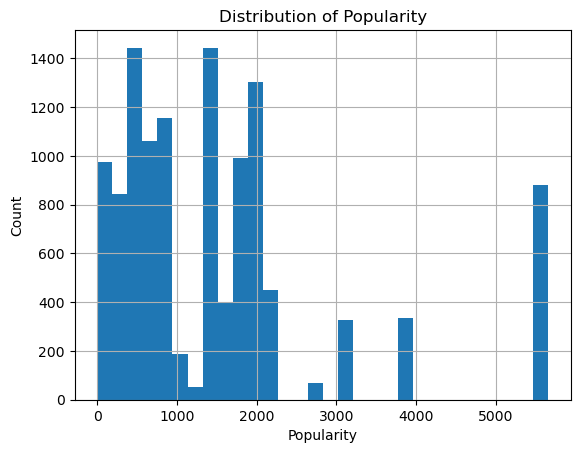

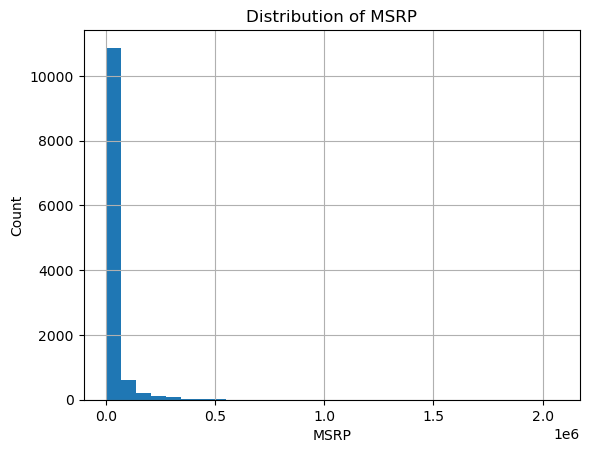

In [28]:
import matplotlib.pyplot as plt

cols = ['Engine HP', 'Engine Cylinders', 'highway MPG', 'city mpg', 'Popularity', 'MSRP']

for col in cols:
    plt.figure()
    df[col].dropna().hist(bins=30)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.show()

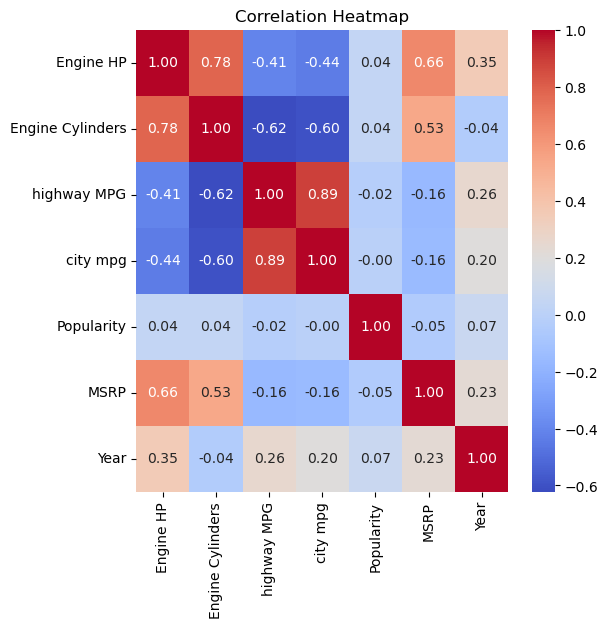

In [29]:
import seaborn as sns

numeric_cols = ['Engine HP', 'Engine Cylinders', 'highway MPG', 'city mpg', 'Popularity', 'MSRP', 'Year']
corr = df[numeric_cols].corr()

plt.figure(figsize=(6, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap')
plt.show()
# READ THIS: values close to +1 or -1 mean strong relationship.
# Expect Engine HP and Engine Cylinders to correlate strongly with MSRP.


### Engine HP vs MSRP — visualizing the relationship behind the correlation heatmap

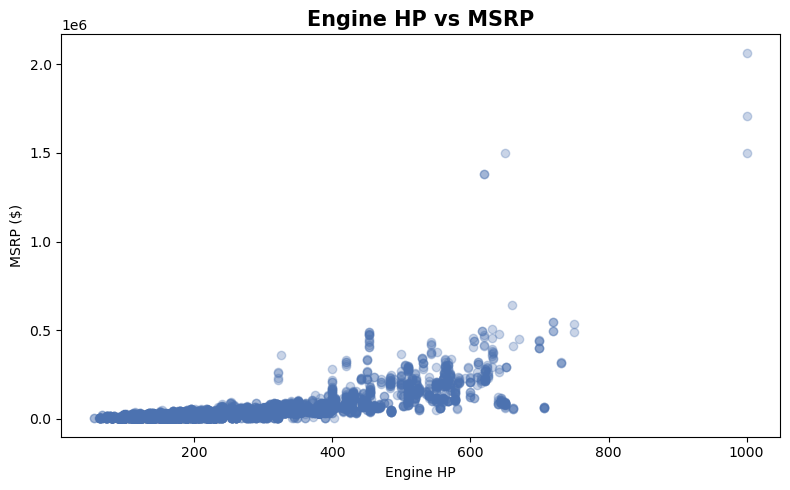

In [30]:
plt.figure(figsize=(8, 5))
plt.scatter(df['Engine HP'], df['MSRP'], alpha=0.3, color='#4C72B0')
plt.title('Engine HP vs MSRP', fontsize=15, fontweight='bold')
plt.xlabel('Engine HP')
plt.ylabel('MSRP ($)')
plt.tight_layout()
plt.savefig('slide_6_hp_vs_price_scatter.png', dpi=200)
plt.show()

## Key Findings & Recommendations

- **Price scales strongly with engine size** (4-cyl ~$24K → 8-cyl ~$61K → 12-cyl ~$285K). Engine size/performance tier is a reliable basis for pricing segmentation.
- **Electric vehicles behave differently** — near-zero cylinders, extreme MPG-equivalent values, and premium pricing. They should be benchmarked separately from gas vehicles, not blended into the same mileage/price comparisons.
- **All 6 core features are right-skewed**, with 5-8% of rows flagged as IQR outliers in each. These outliers are genuine (supercars, EVs), not data errors — they should be kept, not removed, in any downstream pricing model.
- **"Popularity" reflects brand buzz, not sales volume** (Ferrari ranks in the top 5). Any business use of this metric should account for that distinction.
- **Engine HP shows the strongest visual and correlational relationship with MSRP**, making it the single most useful lever for a quick price estimate.

**Next step:** a price-prediction model (Linear Regression / Random Forest) is being built on top of these findings — see the accompanying model notebook/script.
